In [44]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated, Literal
import operator
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
from langgraph.graph import  StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

In [45]:
class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3-5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' and 'examples' exactly once in the plan.",
    )
class Plan(BaseModel):
    blog_title: str = Field(..., description="A catchy and highly technical title for the blog post.")
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]


class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str


In [46]:
llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')
llm = ChatGroq(model="llama-3.1-8b-instant")
llm = ChatOllama(model="llama3")

In [47]:
def orchestrator(state: State):
    system_message = (
        "You are a senior technical writer and developer advocate. Your job is to produce a highly actionable outline for a technical blog post.\n\n"
        "Hard requirements:\n"
        "- Create 5-7 sections (tasks) that fit a technical blog.\n"
        "- Each section must include:\n"
        "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
        "  2) 3-5 bullets that are concrete, specific, and non-overlapping\n"
        "  3) target word count (120-450)\n"
        "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
        "Make it technical (not generic):\n"
        "- Assume the reader is a developer; use correct terminology.\n"
        "- Prefer design/engineering structure: problem → intuition → approach → implementation → trade-offs → testing/observability → conclusion.\n"
        "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X').\n"
        "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
        "  * a minimal working example (MWE) or code sketch\n"
        "  * edge cases / failure modes\n"
        "  * performance/cost considerations\n"
        "  * security/privacy considerations (if relevant)\n"
        "  * debugging tips / observability (logs, metrics, traces)\n"
        "- Avoid vague bullets like 'Explain X'. Every bullet should state what to build/compare/measure/verify.\n\n"
        "Ordering guidance:\n"
        "- Start with a crisp intro and problem framing.\n"
        "- Build core concepts before advanced details.\n"
        "- Include one section for common mistakes and how to avoid them.\n"
        "- End with a practical summary/checklist and next steps.\n\n"
        "CRITICAL: Output must strictly match the Plan schema. Ensure you generate a compelling 'blog_title' alongside the tasks."
    )
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_message),
        ("human", "Topic: {topic}")
    ])

    chain = prompt | llm.with_structured_output(Plan)
  
    result = chain.invoke({"topic", state["topic"]})

    return {"plan": result}


In [48]:
def fanout(state: State):
    return [
        Send("worker", {"topic":state["topic"], "plan": state['plan'],"task": task}) for task in state["plan"].tasks
        ]

In [49]:
def worker(state: State):
    task = state["task"]
    topic = state["topic"]
    plan = state["plan"]
    blog_title = plan.blog_title
    bullets_text = "\n- " + "\n- ".join(task.bullets)

    system_message = (
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_message),
        ("human", "Blog: {blog_title}\nTopic: {topic}\nGoal : {goal}\nSection: {task_title}\Audience: {audience}\nTone: {tone}, Section type: {section_type}\nTarget words: {target_words}\nBullets:{bullets_text}\nReturn only the section content in Markdown.")
    ])

    chain = prompt | llm
    result = chain.invoke({"blog_title":blog_title,"topic": topic,"goal": task.goal, "task_title":task.title, "audience": plan.audience, "tone": plan.tone, "section_type":task.section_type, "target_words":task.target_words, "bullets_text":{bullets_text}}).content.strip()

    return {"sections": [result]}

<>:34: SyntaxWarning: invalid escape sequence '\A'
<>:34: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_25286/1540887260.py:34: SyntaxWarning: invalid escape sequence '\A'
  ("human", "Blog: {blog_title}\nTopic: {topic}\nGoal : {goal}\nSection: {task_title}\Audience: {audience}\nTone: {tone}, Section type: {section_type}\nTarget words: {target_words}\nBullets:{bullets_text}\nReturn only the section content in Markdown.")


In [50]:
from pathlib import Path


def reducer(state: State):
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

<unknown>:34: SyntaxWarning: invalid escape sequence '\A'


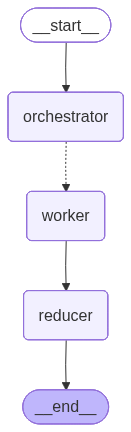

In [51]:
graph = StateGraph(State)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)
graph.add_edge(START, "orchestrator")

graph.add_conditional_edges("orchestrator", fanout, ["worker"])

graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)


workflow = graph.compile()

workflow

In [52]:
workflow.invoke({"topic": "Write a blog on LLMs", "sections": []})

{'topic': 'Write a blog on LLMs',
 'plan': Plan(blog_title='Unlocking the Power of Large Language Models (LLMs): A Step-by-Step Guide', audience='Developers', tone='Technical', tasks=[Task(id=1, title='Introduction to LLMs and Their Potential Impact', goal='Understand the capabilities and limitations of Large Language Models (LLMs) and how they can benefit your projects.', bullets=['Show a minimal working example of an LLM-powered chatbot', 'Explain the concept of masked language modeling', 'Illustrate the difference between LLMs and traditional NLP approaches'], target_words=150, section_type='intro'), Task(id=2, title='Choosing the Right Architecture for Your Task', goal='Select a suitable architecture and hyperparameters for your specific use case, considering factors such as data size, compute resources, and desired level of accuracy.', bullets=['Provide a code snippet for implementing a transformer-based LLM', 'Discuss the advantages and limitations of different architectures (e.g